In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xalglib as alg
from areafit import __roots, areafit_fill, areafit_cut

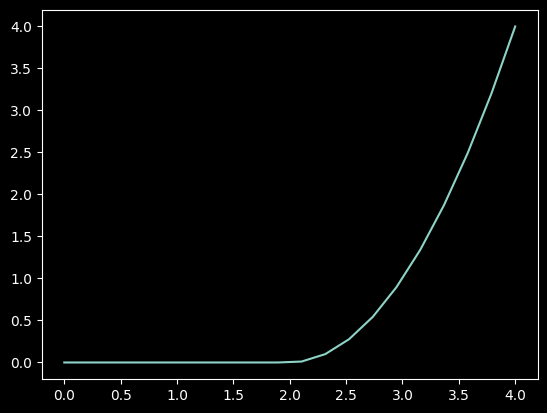

[4.000000000000023, -4.000000000000018, 1.0000000000000033]

In [2]:
u = np.linspace(0,4, 20)
u_start = 2.0
v = np.power(u - u_start, 2)
v[u <= u_start] = 0.0
plt.plot(u, v)
plt.show()

r = __roots(u, v)
if len(r) != 1:
    raise Exception("Could not find zero crossing point")

u_start = r[0]

# grab only the portion after zero
idx = v > 0
u = u[idx]
v = v[idx]

poly, rep = alg.polynomialfit(u, v, len(u), 3)
coeff = alg.polynomialbar2pow(poly, 0.0, 1.0)

coeff

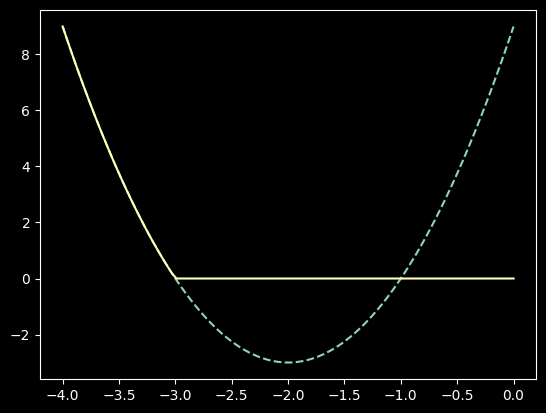

([9.000000000000004, 12.000000000000005, 3.0000000000000018],
 np.float64(-2.9999999999999996),
 1.2517239542068158e-15)

In [6]:
w = 6
s = 3
u0 = -3

u = np.linspace(-4, 0, 100)
v = -(u-u0)*w + np.power(u - u0, 2)*s

coeffs, u_offset, err = areafit_cut(u, v)

v_fit = coeffs[0] + coeffs[1]*u + coeffs[2]*np.power(u, 2)
v_fit[u > u_offset] = 0

plt.plot(u, v, '--')
plt.plot(u, v_fit)
plt.show()

coeffs, u_offset, err

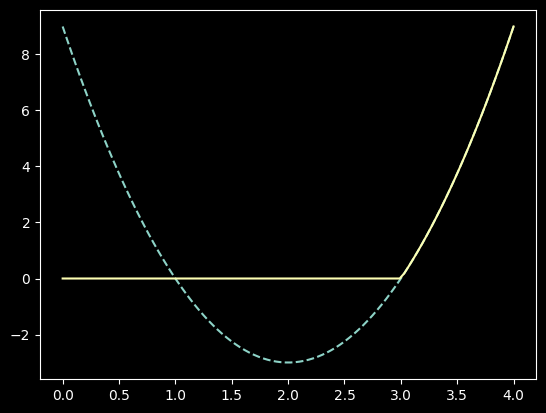

([9.000000000000004, -12.000000000000005, 3.0000000000000013],
 np.float64(3.0),
 1.890057617783896e-15)

In [7]:
w = 6
s = 3
u0 = 3

u = np.linspace(0, 4, 100)
v = (u-u0)*w + np.power(u - u0, 2)*s

coeffs, u_offset, err = areafit_fill(u, v)

v_fit = coeffs[0] + coeffs[1]*u + coeffs[2]*np.power(u, 2)
v_fit[u < u_offset] = 0

plt.plot(u, v, '--')
plt.plot(u, v_fit)
plt.show()

coeffs, u_offset, err